# Machine Learning Model Training & Hyperparameter Optimization


In [1]:
%pip install -q optuna hyperopt

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import optuna
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

RANDOM_STATE = 42
N_TRIALS = 30


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 19.2 MB/s eta 0:00:00


## 1. Bengaluru House Prices

In [3]:
df_house = pd.read_csv("bengaluru_house_prices.csv")

print("Shape:", df_house.shape)
df_house.head()


Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df_house.info()
print("\nMissing values:")
print(df_house.isnull().sum().sort_values(ascending=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB

Missing values:
society         5502
balcony          609
bath              73
size              16
location           1
area_type          0
availability       0
total_sqft         0
price              0
dtype: int64


### Data Cleaning

- Convert `total_sqft` ranges to their average.
- Extract `bhk` from `size`.
- Remove unused columns.
- Remove rows missing important values.
- Group rare locations into `other`.
- Remove obvious price-per-square-foot and BHK outliers.

In [5]:
def convert_sqft(value):
    try:
        value = str(value).strip()
        if "-" in value:
            low, high = value.split("-")
            return (float(low) + float(high)) / 2
        return float(value)
    except:
        return np.nan


df_house["total_sqft"] = df_house["total_sqft"].apply(convert_sqft)
df_house["bhk"] = df_house["size"].astype(str).str.extract(r"(\d+)")[0].astype(float)

df_house = df_house.drop(columns=["society", "availability", "size"])
df_house = df_house.dropna(subset=["total_sqft", "bhk", "price", "location"])

df_house = df_house[
    (df_house["total_sqft"] / df_house["bhk"]) >= 300
].copy()

df_house["location"] = df_house["location"].astype(str).str.strip()

location_counts = df_house["location"].value_counts()
rare_locations = location_counts[location_counts <= 10].index

df_house["location"] = df_house["location"].apply(
    lambda x: "other" if x in rare_locations else x
)

df_house["price_per_sqft"] = (
    df_house["price"] * 100000 / df_house["total_sqft"]
)

print("Shape after cleaning:", df_house.shape)


Shape after cleaning: (12513, 8)


In [6]:
def remove_pps_outliers(df):
    result = []

    for location, group in df.groupby("location"):
        mean = group["price_per_sqft"].mean()
        std = group["price_per_sqft"].std()

        if pd.isna(std) or std == 0:
            result.append(group)
        else:
            result.append(
                group[
                    (group["price_per_sqft"] >= mean - std)
                    & (group["price_per_sqft"] <= mean + std)
                ]
            )

    return pd.concat(result)


df_house = remove_pps_outliers(df_house)


def remove_bhk_outliers(df):
    remove_index = []

    for location, group in df.groupby("location"):
        stats = {}

        for bhk, bhk_group in group.groupby("bhk"):
            stats[bhk] = {
                "mean": bhk_group["price_per_sqft"].mean(),
                "count": len(bhk_group)
            }

        for bhk, bhk_group in group.groupby("bhk"):
            previous = stats.get(bhk - 1)

            if previous and previous["count"] > 5:
                remove_index.extend(
                    bhk_group[
                        bhk_group["price_per_sqft"] < previous["mean"]
                    ].index
                )

    return df.drop(index=remove_index)


df_house = remove_bhk_outliers(df_house)
df_house = df_house.drop(columns="price_per_sqft")

print("Final shape:", df_house.shape)


Final shape: (7340, 7)


In [7]:
df_house = pd.get_dummies(
    df_house,
    columns=["area_type", "location"],
    drop_first=True,
    dtype=int
)

X_house = df_house.drop(columns="price")
y_house = df_house["price"]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house,
    y_house,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_train_h_opt, X_valid_h, y_train_h_opt, y_valid_h = train_test_split(
    X_train_h,
    y_train_h,
    test_size=0.20,
    random_state=RANDOM_STATE
)

medians = X_train_h_opt.median()

X_train_h_opt = X_train_h_opt.fillna(medians)
X_valid_h = X_valid_h.fillna(medians)
X_train_h = X_train_h.fillna(medians)
X_test_h = X_test_h.fillna(medians)

print("Train:", X_train_h.shape)
print("Validation:", X_valid_h.shape)
print("Test:", X_test_h.shape)


Train: (5872, 229)
Validation: (1175, 229)
Test: (1468, 229)


### Optuna

In [8]:
def house_optuna(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5)
    }

    model = RandomForestRegressor(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train_h_opt, y_train_h_opt)
    pred = model.predict(X_valid_h)

    return r2_score(y_valid_h, pred)


study_house = optuna.create_study(direction="maximize")
study_house.optimize(
    house_optuna,
    n_trials=N_TRIALS,
    show_progress_bar=False
)

print("Best validation R2:", round(study_house.best_value, 4))
print("Best parameters:", study_house.best_params)


[I 2026-08-15 18:06:26,864] A new study created in memory with name: no-name-13206225-9c79-4910-96b3-9f843fafe4fb
[I 2026-08-15 18:06:43,116] Trial 0 finished with value: 0.8295105125006619 and parameters: {'n_estimators': 455, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8295105125006619.
[I 2026-08-15 18:06:50,859] Trial 1 finished with value: 0.8588245230651013 and parameters: {'n_estimators': 314, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.8588245230651013.
[I 2026-08-15 18:06:54,935] Trial 2 finished with value: 0.8304683987565264 and parameters: {'n_estimators': 124, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8588245230651013.
[I 2026-08-15 18:07:00,380] Trial 3 finished with value: 0.8399708670666137 and parameters: {'n_estimators': 145, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 1 with value

Best validation R2: 0.8768
Best parameters: {'n_estimators': 216, 'max_depth': 27, 'min_samples_split': 10, 'min_samples_leaf': 1}


### Hyperopt

In [9]:
def house_hyperopt(params):
    params = {
        "n_estimators": int(params["n_estimators"]),
        "max_depth": int(params["max_depth"]),
        "min_samples_split": int(params["min_samples_split"]),
        "min_samples_leaf": int(params["min_samples_leaf"])
    }

    model = RandomForestRegressor(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train_h_opt, y_train_h_opt)
    pred = model.predict(X_valid_h)

    return {
        "loss": -r2_score(y_valid_h, pred),
        "status": STATUS_OK
    }


house_space = {
    "n_estimators": hp.quniform("n_estimators", 100, 500, 1),
    "max_depth": hp.quniform("max_depth", 5, 30, 1),
    "min_samples_split": hp.quniform("min_samples_split", 2, 10, 1),
    "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 5, 1)
}

house_trials = Trials()

best_house = fmin(
    fn=house_hyperopt,
    space=house_space,
    algo=tpe.suggest,
    max_evals=N_TRIALS,
    trials=house_trials,
    rstate=np.random.default_rng(RANDOM_STATE)
)

best_house = {key: int(value) for key, value in best_house.items()}

print("Best parameters:", best_house)


100%|██████████| 30/30 [05:10<00:00, 10.35s/trial, best loss: -0.8781688010494244]
Best parameters: {'max_depth': 27, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 380}


### Final House Price Models

In [10]:
house_optuna_model = RandomForestRegressor(
    **study_house.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

house_optuna_model.fit(X_train_h, y_train_h)
house_optuna_pred = house_optuna_model.predict(X_test_h)


house_hyperopt_model = RandomForestRegressor(
    **best_house,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

house_hyperopt_model.fit(X_train_h, y_train_h)
house_hyperopt_pred = house_hyperopt_model.predict(X_test_h)


house_results = pd.DataFrame({
    "Model": [
        "Optuna + Random Forest",
        "Hyperopt + Random Forest"
    ],
    "R2": [
        r2_score(y_test_h, house_optuna_pred),
        r2_score(y_test_h, house_hyperopt_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_h, house_optuna_pred)),
        np.sqrt(mean_squared_error(y_test_h, house_hyperopt_pred))
    ]
})

house_results.round(4)


,Model,R2,RMSE
0,Optuna + Random Forest,0.8737,29.1218
1,Hyperopt + Random Forest,0.8736,29.1304


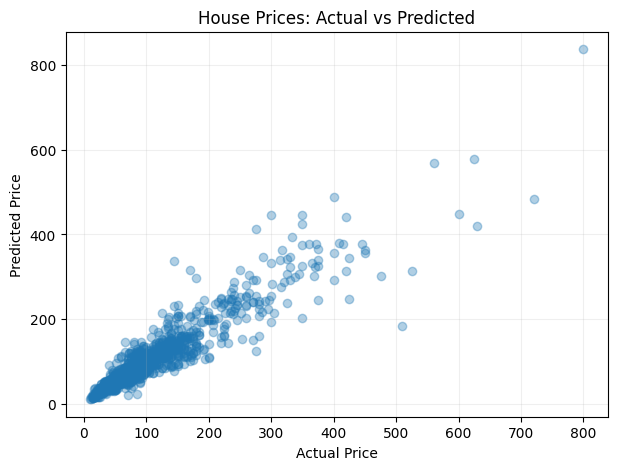

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_h, house_optuna_pred, alpha=0.35)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Prices: Actual vs Predicted")
plt.grid(alpha=0.2)
plt.show()


## 2. Churn Modelling

In [14]:
df_churn = pd.read_csv("Churn_Modelling.csv")

print("Shape:", df_churn.shape)
df_churn.head()


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df_churn.info()

print("\nTarget distribution:")
print(df_churn["Exited"].value_counts())

print("\nMissing values:")
print(df_churn.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Missing values:
Ro

### Data Cleaning

Remove identifier columns and encode the categorical columns using one-hot encoding.

In [18]:
df_churn = df_churn.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
)

df_churn = pd.get_dummies(
    df_churn,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)

X_churn = df_churn.drop(columns="Exited")
y_churn = df_churn["Exited"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_churn,
    y_churn,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_churn
)

X_train_c_opt, X_valid_c, y_train_c_opt, y_valid_c = train_test_split(
    X_train_c,
    y_train_c,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_c
)

print("Train:", X_train_c.shape)
print("Validation:", X_valid_c.shape)
print("Test:", X_test_c.shape)


KeyError: "['RowNumber', 'CustomerId', 'Surname'] not found in axis"

#الايرور عشان انا رنيت تاني بعد ما حذف ال3 اعمده الي قلتلو يحذفهم اول مره  

### Optuna

In [19]:
def churn_optuna(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5)
    }

    model = RandomForestClassifier(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train_c_opt, y_train_c_opt)
    pred = model.predict(X_valid_c)

    return accuracy_score(y_valid_c, pred)


study_churn = optuna.create_study(direction="maximize")
study_churn.optimize(
    churn_optuna,
    n_trials=N_TRIALS,
    show_progress_bar=False
)

print("Best validation accuracy:", round(study_churn.best_value, 4))
print("Best parameters:", study_churn.best_params)


[I 2026-08-15 18:23:31,591] A new study created in memory with name: no-name-95fc4e34-000d-4213-9d27-32bd20989e02
[I 2026-08-15 18:23:33,312] Trial 0 finished with value: 0.855625 and parameters: {'n_estimators': 312, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.855625.
[I 2026-08-15 18:23:36,606] Trial 1 finished with value: 0.858125 and parameters: {'n_estimators': 437, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.858125.
[I 2026-08-15 18:23:41,612] Trial 2 finished with value: 0.861875 and parameters: {'n_estimators': 445, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.861875.
[I 2026-08-15 18:23:42,869] Trial 3 finished with value: 0.84375 and parameters: {'n_estimators': 275, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.861875.
[I 2026-08-15 18:23:44,945] Trial 4 finished with value: 0.8

Best validation accuracy: 0.8644
Best parameters: {'n_estimators': 136, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 4}


### Hyperopt

In [20]:
def churn_hyperopt(params):
    params = {
        "n_estimators": int(params["n_estimators"]),
        "max_depth": int(params["max_depth"]),
        "min_samples_split": int(params["min_samples_split"]),
        "min_samples_leaf": int(params["min_samples_leaf"])
    }

    model = RandomForestClassifier(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train_c_opt, y_train_c_opt)
    pred = model.predict(X_valid_c)

    return {
        "loss": -accuracy_score(y_valid_c, pred),
        "status": STATUS_OK
    }


churn_space = {
    "n_estimators": hp.quniform("n_estimators", 100, 500, 1),
    "max_depth": hp.quniform("max_depth", 3, 25, 1),
    "min_samples_split": hp.quniform("min_samples_split", 2, 10, 1),
    "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 5, 1)
}

churn_trials = Trials()

best_churn = fmin(
    fn=churn_hyperopt,
    space=churn_space,
    algo=tpe.suggest,
    max_evals=N_TRIALS,
    trials=churn_trials,
    rstate=np.random.default_rng(RANDOM_STATE)
)

best_churn = {key: int(value) for key, value in best_churn.items()}

print("Best parameters:", best_churn)


100%|██████████| 30/30 [01:16<00:00,  2.55s/trial, best loss: -0.864375]
Best parameters: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 335}


### Final Churn Models

In [23]:
churn_optuna_model = RandomForestClassifier(
    **study_churn.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

churn_optuna_model.fit(X_train_c, y_train_c)
churn_optuna_pred = churn_optuna_model.predict(X_test_c)


churn_hyperopt_model = RandomForestClassifier(
    **best_churn,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

churn_hyperopt_model.fit(X_train_c, y_train_c)
churn_hyperopt_pred = churn_hyperopt_model.predict(X_test_c)


def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }


churn_results = pd.DataFrame([
    {
        "Model": "Optuna + Random Forest",
        **classification_metrics(y_test_c, churn_optuna_pred)
    },
    {
        "Model": "Hyperopt + Random Forest",
        **classification_metrics(y_test_c, churn_hyperopt_pred)
    }
])

churn_results.round(4)


,Model,Accuracy,Precision,Recall,F1
0,Optuna + Random Forest,0.8665,0.7941,0.4644,0.5860
1,Hyperopt + Random Forest,0.8680,0.8122,0.4570,0.5849


In [24]:
print("Optuna Model")
print(classification_report(y_test_c, churn_optuna_pred, zero_division=0))

print("Hyperopt Model")
print(classification_report(y_test_c, churn_hyperopt_pred, zero_division=0))


Optuna Model
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.46      0.59       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

Hyperopt Model
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.81      0.46      0.58       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



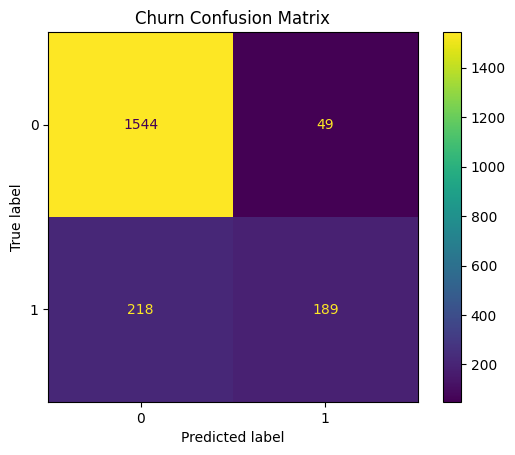

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test_c,
    churn_optuna_pred
)

plt.title("Churn Confusion Matrix")
plt.show()


## Final Comparison

In [26]:
print("HOUSE PRICE REGRESSION")
display(house_results.round(4))

print("CHURN CLASSIFICATION")
display(churn_results.round(4))


HOUSE PRICE REGRESSION


,Model,R2,RMSE
0,Optuna + Random Forest,0.8737,29.1218
1,Hyperopt + Random Forest,0.8736,29.1304


CHURN CLASSIFICATION


,Model,Accuracy,Precision,Recall,F1
0,Optuna + Random Forest,0.8665,0.7941,0.4644,0.5860
1,Hyperopt + Random Forest,0.8680,0.8122,0.4570,0.5849


## Conclusion

Both datasets were trained using Random Forest models and optimized with Optuna and Hyperopt.

- House prices were evaluated using **R²** and **RMSE**.
- Churn was evaluated using **Accuracy, Precision, Recall, and F1-score**.
- The test sets were kept separate from hyperparameter optimization.